# Brain Connectivity Modelling Through Joint Estimation of Parcels and Gradients

### Developer
**Aref Miri Rekavandi**

---

## Citation & Copyright Notice

If you use this code, framework, or parts of this repository in your research or academic work, please cite the following work:

> Aref Miri Rekavandi, Saad Jbabdi, Stephen M. Smith, "Brain Connectivity Modelling Through Joint Estimation of Parcels and Gradients."  bioRxiv (2026)  

Please preserve all copyright and attribution notices when reusing or modifying this code.

---

## Reproducibility

To ensure reproducibility, random seeds are fixed where applicable.

## Environment Setup

Follow the instruction in README.md file.


In [1]:
# ============================================================
# Standard library
# ============================================================
import random

# ============================================================
# Numerical computing
# ============================================================
import numpy as np
import scipy.ndimage as nd
from scipy.linalg import eigh, fractional_matrix_power
from scipy.sparse.linalg import eigsh

# ============================================================
# Machine learning / dimensionality reduction
# ============================================================
from sklearn.decomposition import FastICA, PCA
from sklearn.manifold import Isomap
import umap

# ============================================================
# Visualization
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


# ============================================================
# Image processing
# ============================================================
from skimage.exposure import match_histograms


# ============================================================
# Neuroimaging / gradient analysis
# ============================================================
from brainspace.gradient import GradientMaps

# Install:
# pip install git+https://github.com/arekavandi/RobustPCA
from RobustPCA.rpca import RobustPCA

# Custom utilities:
# https://github.com/arekavandi/utils_gradients
from functions import utils_gradients as utils

# ============================================================
# Reproducibility
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

/opt/anaconda3/envs/Gradients/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


A single snapshot in time:


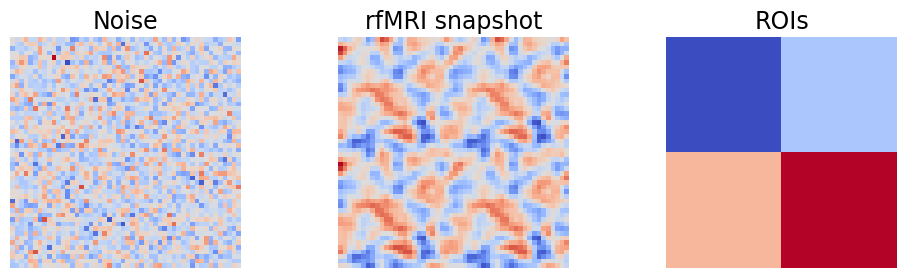

In [2]:
V = 50        # Spatial grid size (V x V voxels)
T = 2000      # Number of time points (time series length)


bx1 = 25      # horizontal split index
by1 = 25      # vertical split index for ROI partitioning
by2 = 25      # secondary ROI boundary (symmetric split)

g_w = 2       # gradient component weight
l_w = 3       # low-rank signal weight
n_w = 0.01    # noise weight

X=np.random.normal(loc=0.0, scale=1, size=(T, V*V))

#create low-rank data matrix
S1v=np.zeros((V,V))
S1v[0:bx1,:]=1
S1=np.reshape(S1v,(V*V,1))
S2v=np.zeros((V,V))
S2v[:,0:bx1]=1
S2=np.reshape(S2v,(V*V,1))
T1=np.random.normal(loc=0.0, scale=2, size=(T, 1))
T2=np.random.normal(loc=0.0, scale=2, size=(T, 1))
    

G11 = np.random.normal(loc=0.0, scale=15, size=(T, V//2, V//2))
G22 = G11.copy()
parcels2d=np.zeros((V,V))
parcels2d[bx1:,:by1]=2*np.ones((V-bx1,by1))
parcels2d[:bx1:,by1:]=np.ones((bx1,V-by1))
parcels2d[bx1:,by1:]=3*np.ones((V-bx1,V-by1))
parcels=parcels2d.flatten()


top = np.concatenate([G11, G22], axis=2)   # (T, V/2, V)
bottom = np.concatenate([G22, G11], axis=2)  # (T, V/2, V)
G1 = np.concatenate([top, bottom], axis=1)   # (T, V, V)
G2=np.zeros_like(G1); G3=np.zeros_like(G1); G4=np.zeros_like(G1)

RoI1v=np.zeros((V,V));RoI2v=np.zeros_like(RoI1v);RoI3v=np.zeros_like(RoI1v);RoI4v=np.zeros_like(RoI1v);
RoI1v[:bx1,:by1]=1; RoI2v[:bx1,by1:]=1; RoI3v[bx1:,:by2]=1; RoI4v[bx1:,by2:]=1

sigma=np.zeros((4,2))
sigma[0,:]=[1,1]
sigma[1,:]=[1,1]
sigma[2,:]=[1,1]
sigma[3,:]=[1,1]

#smooth G1 spatially

for t in range(T):                    
    G2[t,:,:]=nd.gaussian_filter(G1[t,:,:], sigma=sigma[1,:])
    G3[t,:,:]=nd.gaussian_filter(G1[t,:,:], sigma=sigma[2,:])
    G4[t,:,:]=nd.gaussian_filter(G1[t,:,:], sigma=sigma[3,:])
    G1[t,:,:]=nd.gaussian_filter(G1[t,:,:], sigma=sigma[0,:])

#re-zero outside of ROIs
G1[:,RoI1v==0]=0;G2[:,RoI2v==0]=0;G3[:,RoI3v==0]=0;G4[:,RoI4v==0]=0
    
G1n=np.reshape(G1,(T,V*V)); G2n=np.reshape(G2,(T,V*V)); G3n=np.reshape(G3,(T,V*V)); G4n=np.reshape(G4,(T,V*V)); Gn=G1n+G2n+G3n+G4n;


# add in a rank2 component to form Data
Data=n_w*X+g_w*Gn+l_w*(T1@S1.T+T2@S2.T)

print('A single snapshot in time:')
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax in axes:
    ax.axis('off')
axes[0].imshow(np.reshape(X,(T,V,V))[0,:,:],cmap='coolwarm')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_title('Noise', fontsize=17)

axes[1].imshow(np.reshape(Data,(T,V,V))[0,:,:],cmap='coolwarm')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_title('rfMRI snapshot', fontsize=17)

axes[2].imshow(parcels2d, cmap='coolwarm')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')
axes[2].set_title("ROIs", fontsize=17)
plt.show()

unique_vals = np.unique(parcels, return_index=True)
vals_in_order = unique_vals[0][np.argsort(unique_vals[1])]

# Collect indices for each value in that order
sorted_indices = np.concatenate([np.where(parcels == v)[0] for v in vals_in_order])
unsort_idx = np.argsort(sorted_indices)

Data=Data[:,sorted_indices]
X=X[:,sorted_indices]
Gn=Gn[:,sorted_indices]
S1=S1[sorted_indices]
S2=S2[sorted_indices]
Gonly=(n_w/2)*X+g_w*Gn
Lonly=(n_w/2)*X+l_w*(T1@S1.T+T2@S2.T)

Dense_C_train=np.corrcoef(Data[:int(T/2),:].T)
Dense_C_valid=np.corrcoef(Data[int(T/2):,:].T)


Dense_C_train=np.corrcoef(Data[:int(T/2),:].T)
Dense_C_valid=np.corrcoef(Data[int(T/2):,:].T)
train_val_corr_full=np.corrcoef(Dense_C_valid.flatten(),Dense_C_train.flatten())[0,1]

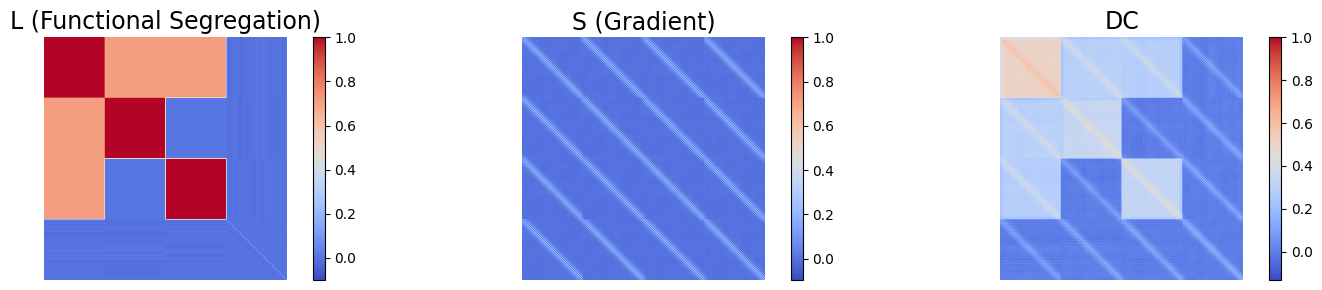

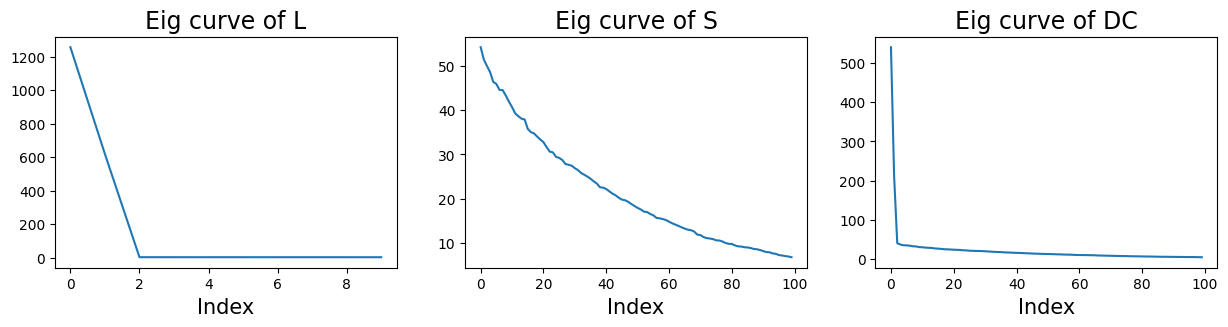

First eigenvalue:540.0415621439935, Second: 211.3010452053636, Third: 40.631986017377095


In [3]:
# Estimating the eigen-curves for S, L, and DC

fig, axs = plt.subplots(1, 3, figsize=(15, 3))
for ax in axs:
    ax.axis('off')

im0 = axs[0].imshow(np.corrcoef(Lonly.T), cmap='coolwarm')
axs[0].set_title('L (Functional Segregation)', fontsize=17)
fig.colorbar(im0, ax=axs[0])  # <-- attach colorbar to this axis
# Subplot 2
im1 = axs[1].imshow(np.corrcoef(Gonly.T), cmap='coolwarm')
axs[1].set_title('S (Gradient)', fontsize=17)
fig.colorbar(im1, ax=axs[1])

# Subplot 3
im2 = axs[2].imshow(Dense_C_train, cmap='coolwarm')
axs[2].set_title('DC', fontsize=17)
fig.colorbar(im2, ax=axs[2])
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(15, 3))

tempdense=np.corrcoef(Lonly.T)
leftU, eigenvalues, rightV = np.linalg.svd(tempdense)
axs[0].plot(eigenvalues[0:10])
axs[0].set_title('Eig curve of L', fontsize=17)
axs[0].set_xlabel('Index', fontsize=15)
#axs[0].set_ylabel('Value', fontsize=15)
tempdense=np.corrcoef(Gonly.T)
leftU, eigenvalues, rightV = np.linalg.svd(tempdense)
axs[1].plot(eigenvalues[0:100])
axs[1].set_title('Eig curve of S', fontsize=17)
axs[1].set_xlabel('Index', fontsize=15)
#axs[1].set_ylabel('Value', fontsize=15)
leftU, eigenvalues, rightV = np.linalg.svd(Dense_C_train)
axs[2].plot(eigenvalues[0:100])
axs[2].set_title('Eig curve of DC', fontsize=17)
axs[2].set_xlabel('Index', fontsize=15)
#axs[2].set_ylabel('Value', fontsize=15)
plt.show()
print(f'First eigenvalue:{eigenvalues[0]}, Second: {eigenvalues[1]}, Third: {eigenvalues[2]}')

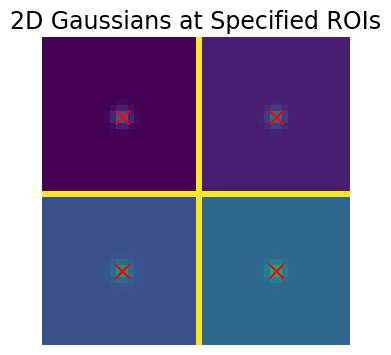

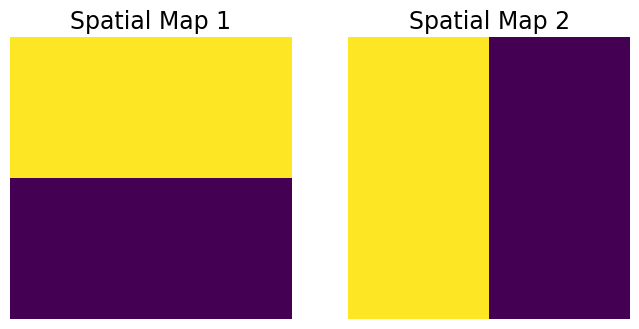

In [4]:
# Visualisation of ROIs and their smoothing kernels together with spatial maps of low-rank components

N = V  

# Define the coordinates where Gaussians will be centered
centers = [(bx1/2, by1/2), (bx1/2,by1+(V-by1)/2), (bx1+(V-bx1)/2, by2/2), (bx1+(V-bx1)/2, by2+(V-by2)/2)]
centers_fake = [(by1/2,bx1/2), (by1+(V-by1)/2,bx1/2), (by2/2,bx1+(V-bx1)/2), (by2+(V-by2)/2,bx1+(V-bx1)/2)]
# Generate a grid for the matrix
x = np.linspace(0, N - 1, N)
y = np.linspace(0, N - 1, N)
X, Y = np.meshgrid(x, y)


Z = np.zeros((N, N))

Z[:by1,:bx1]=0; Z[by1:,:bx1]=0.25; Z[:by2,bx1:]=0.75; Z[by2:,bx1:]=1
Z[:,bx1]=3
Z[by1,:bx1]=3
Z[by2,bx1:]=3

# Function to generate a 2D Gaussian
def gaussian(x, y, x0, y0, std):
    return np.exp(-((x - x0)/np.sqrt(2*std[0])) ** 2-((y - y0)/np.sqrt(2*std[1])) ** 2)

# Add Gaussians centered at each specified coordinate
for i, (x0, y0) in enumerate(centers):
    Z += gaussian(X, Y, x0, y0, sigma[i,:])
    
# Plot the result
plt.figure(figsize=(4, 4))
plt.imshow(Z.T, cmap='viridis')
plt.scatter(*zip(*centers_fake), color='red', marker='x', s=100, label='Smoothing Shape')
#plt.legend()
plt.title("2D Gaussians at Specified ROIs", fontsize=17)
plt.xlabel("Y")
plt.ylabel("X")
plt.axis('off')
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
for ax in axs:
    ax.axis('off')
axs[0].imshow(S1v)
axs[0].set_title('Spatial Map 1', fontsize=17)
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[1].imshow(S2v)
axs[1].set_title('Spatial Map 2', fontsize=17)
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')
plt.show()

In [5]:
# Cross-validation range for estimating the maximum rank of L

MR=list(range(0, 20))
M_G=[2]
n_neighbors=10

corr_lr_full=np.zeros((len(M_G),len(MR))); corr_umap_full=np.zeros((len(M_G),len(MR)));

In [6]:
base_full=[]

for i, mr in enumerate(MR):
    if mr>0:
        rpcp = RobustPCA(max_rank=mr, max_iter=200, tol=0.01*Dense_C_train.shape[0]*Dense_C_train.shape[1],use_fbpca=True)
        rpcp.fit(Dense_C_train)
        L = rpcp.get_low_rank()
        S = rpcp.get_sparse()
        base_val_full=np.corrcoef(L.flatten(),Dense_C_valid.flatten())[0,1]
        base_full.append(base_val_full)
    else:
        L=np.zeros_like(Dense_C_train)
        S=Dense_C_train
        base_full.append(0)
        
    for j, m_g in enumerate(M_G):
        print(f'Running UMAP for {mr} low rank components...')
        embedded_U=umap.UMAP(n_components=m_g, metric='euclidean',n_neighbors=20).fit_transform(S)

        approx_dist=np.zeros((V*V,V*V))

        for k in range(m_g):
            approx_dist+=np.abs(np.subtract.outer(embedded_U[:,k],embedded_U[:,k]))**2

        approx_dist=(approx_dist)**0.5
        approx_dense=(np.max(approx_dist)-approx_dist)
        temp1=match_histograms(approx_dense, S)
        w_opt=np.sum(temp1*S)/np.sum(temp1*temp1)
        approx_dense=w_opt*temp1+L
        corr_umap_full[j,i]=(np.corrcoef(approx_dense.flatten(),Dense_C_valid.flatten())[0,1])

        print(f'Running L+S for {mr} low rank components...')
        rpcp = RobustPCA(max_rank=mr+m_g, max_iter=200, tol=0.01*Dense_C_train.shape[0]*Dense_C_train.shape[1],use_fbpca=True)
        rpcp.fit(Dense_C_train)
        L = rpcp.get_low_rank()
        corr_lr_full[j,i]=(np.corrcoef(L.flatten(),Dense_C_valid.flatten())[0,1])

Running UMAP for 0 low rank components...
Running L+S for 0 low rank components...
Starting fitting...


  0%|▏                                          | 1/200 [00:00<01:03,  3.11it/s]


Converged!
Starting fitting...


  0%|▏                                          | 1/200 [00:00<01:11,  2.80it/s]


Converged!
Running UMAP for 1 low rank components...
Running L+S for 1 low rank components...
Starting fitting...


...

Converged!
Starting fitting...


  0%|▏                                          | 1/200 [00:08<27:48,  8.38s/it]


Converged!
Running UMAP for 19 low rank components...
Running L+S for 19 low rank components...
Starting fitting...


  0%|▏                                          | 1/200 [00:08<28:34,  8.62s/it]

Converged!


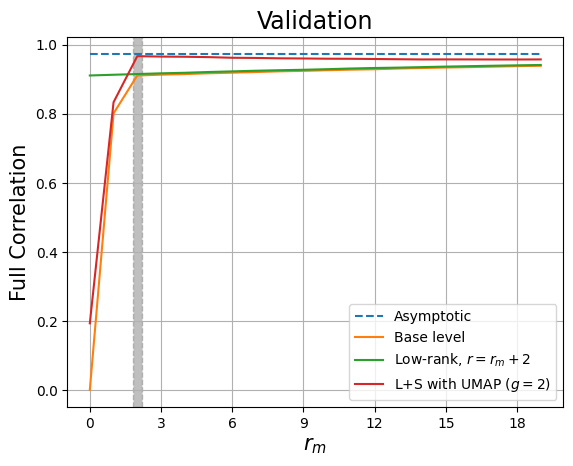

In [7]:
# Visualising the cross-validation results

plt.plot(MR, train_val_corr_full * np.ones(len(MR)), '--', label='Asymptotic')
plt.plot(MR, base_full, label='Base level')
plt.plot(MR, corr_lr_full[0, :], label=f'Low-rank, $r=r_m+{M_G[0]}$')
plt.plot(MR, corr_umap_full[0, :], label=f'L+S with UMAP ($g={M_G[0]}$)')

plt.title('Validation',fontsize=17)
plt.grid(True)
plt.xlabel(r'$r_m$', fontsize=15)
plt.ylabel('Full Correlation', fontsize=15)
plt.legend()

# --- Force integer ticks on x-axis ---
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# --- Add a dashed gray box around the peak index ---
idx = 2  
x_val = MR[idx]
width = (MR[1] - MR[0]) * 0.4  
ymin, ymax = plt.ylim()

plt.axvspan(
    x_val - width / 2,
    x_val + width / 2,
    color='gray',
    linestyle='--',
    alpha=0.5,
    linewidth=1
)

In [8]:
# Repeating the simulation with the optimal rank (MR = 2)

rpcp = RobustPCA(max_rank=2, max_iter=200, tol=0.0001*Dense_C_train.shape[0]*Dense_C_train.shape[1],use_fbpca=True)
rpcp.fit(Dense_C_train)
L = rpcp.get_low_rank()
S = rpcp.get_sparse()

Starting fitting...


  5%|██                                        | 10/200 [00:01<00:26,  7.29it/s]

Converged!


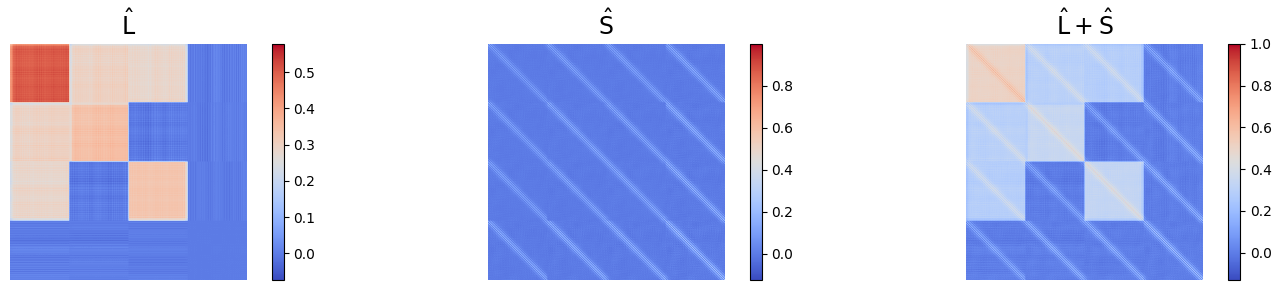

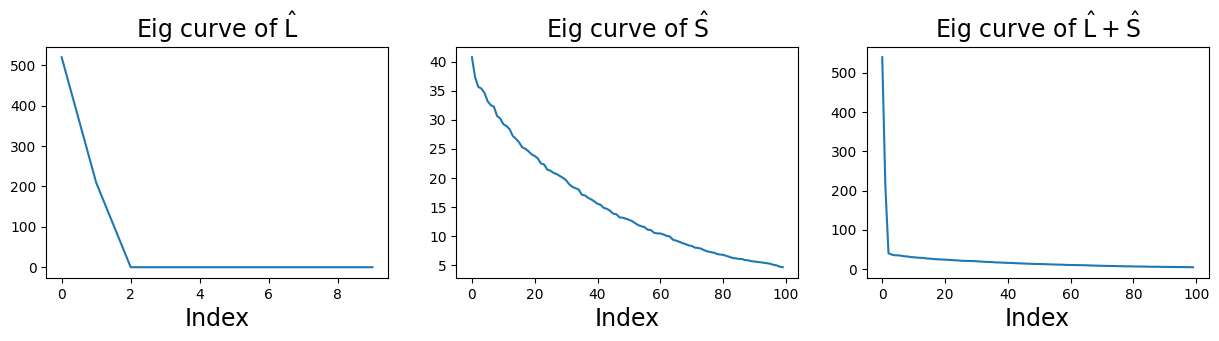

In [9]:
# Estimating the eigen-curves for S_hat, L_hat, and DC_hat

fig, axs = plt.subplots(1, 3, figsize=(15, 3))
for ax in axs:
    ax.axis('off')
im0 = axs[0].imshow(L, cmap='coolwarm')
axs[0].set_title(r'$\hat{\text{L}}$', fontsize=17)
fig.colorbar(im0, ax=axs[0])  

# Subplot 2
im1 = axs[1].imshow(S, cmap='coolwarm')
axs[1].set_title(r'$\hat{\text{S}}$', fontsize=17)
fig.colorbar(im1, ax=axs[1])

# Subplot 3
im2 = axs[2].imshow(L+S, cmap='coolwarm')
axs[2].set_title(r'$\hat{\text{L}}+\hat{\text{S}}$', fontsize=17)
fig.colorbar(im2, ax=axs[2])
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(15, 3))
leftU, eigenvalues, rightV = np.linalg.svd(L)
axs[0].plot(eigenvalues[0:10])
axs[0].set_title(r'Eig curve of $\hat{\text{L}}$', fontsize=17)
axs[0].set_xlabel('Index', fontsize=17)

leftU, eigenvalues, rightV = np.linalg.svd(S)
axs[1].plot(eigenvalues[0:100])
axs[1].set_title(r'Eig curve of $\hat{\text{S}}$', fontsize=17)
axs[1].set_xlabel('Index', fontsize=17)
#axs[1].set_ylabel('Value')
leftU, eigenvalues, rightV = np.linalg.svd(L+S)
axs[2].plot(eigenvalues[0:100])
axs[2].set_title(r'Eig curve of $\hat{\text{L}}+\hat{\text{S}}$', fontsize=17)
axs[2].set_xlabel('Index', fontsize=17)
plt.show()

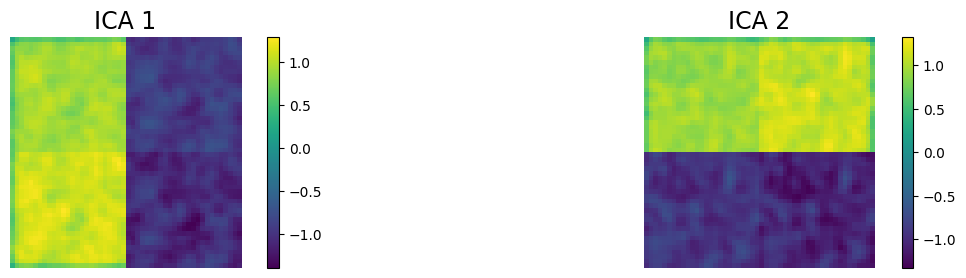

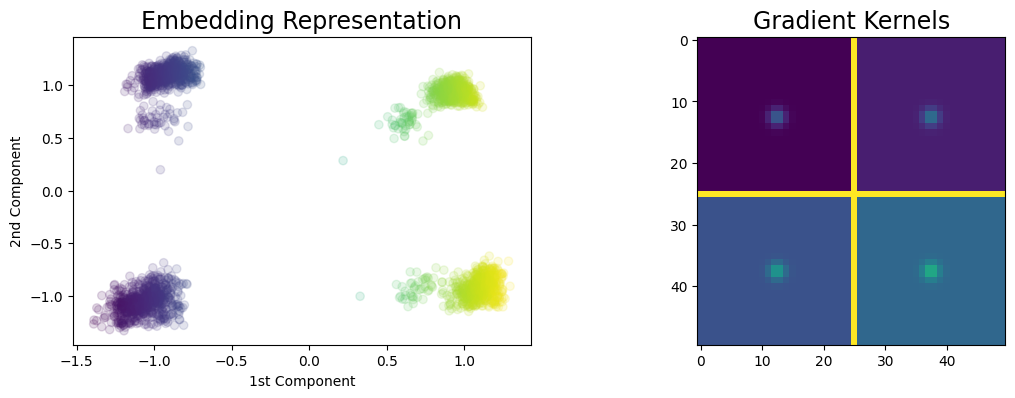

Correlation vs Dense_C: 0.9112541413981515


In [10]:
# ICA with 2 components on L_hat

M1=2
ica = FastICA(n_components=M1, max_iter=1000)
independent_S =ica.fit_transform(L)
independent_A =ica.mixing_
fig, axes = plt.subplots(1, independent_S.shape[1], figsize=(15, 3))
for ax in axes:
    ax.axis('off')

for i in range(independent_S.shape[1]):
    im=axes[i].imshow(np.reshape(independent_S[unsort_idx,i],(V,V)), cmap='viridis')  # Change the colormap if needed
    axes[i].set_title(f'ICA {i+1}', fontsize=17)
    fig.colorbar(im, ax=axes[i], orientation='vertical')
    axes[i].set_xlabel('X', fontsize=17)
    axes[i].set_ylabel('Y', fontsize=17)
plt.show()

if independent_S.shape[1]>2:
    pca=PCA(n_components=2)
    independent_Sr=pca.fit_transform(independent_S)
else:
    independent_Sr=independent_S
    
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].scatter(independent_Sr[:,0],independent_Sr[:,1],c=independent_S[:,0], alpha=0.15, cmap='viridis')
axs[0].set_title('Embedding Representation', fontsize=17)
axs[0].set_xlabel('1st Component')
axs[0].set_ylabel('2nd Component')

im = axs[1].imshow(np.reshape(Z.T,(V,V)),cmap='viridis')
#im=axs[1].imshow(index_pattren,cmap='viridis')
axs[1].set_title('Gradient Kernels', fontsize=17)
plt.show()

print('Correlation vs Dense_C:',np.corrcoef(L.flatten(),Dense_C_valid.flatten())[0,1])

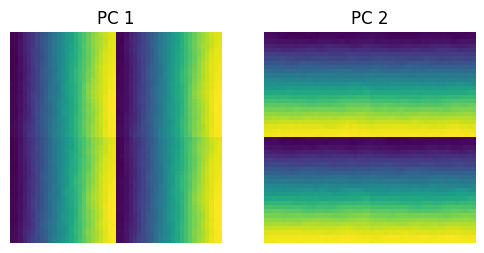

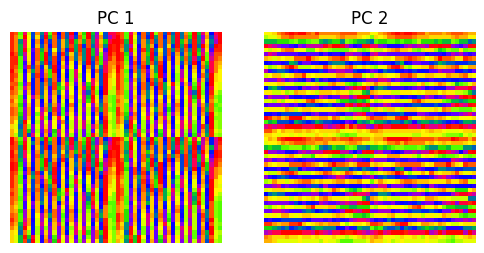

w optimal: 0.8374915422313279
Final DC:


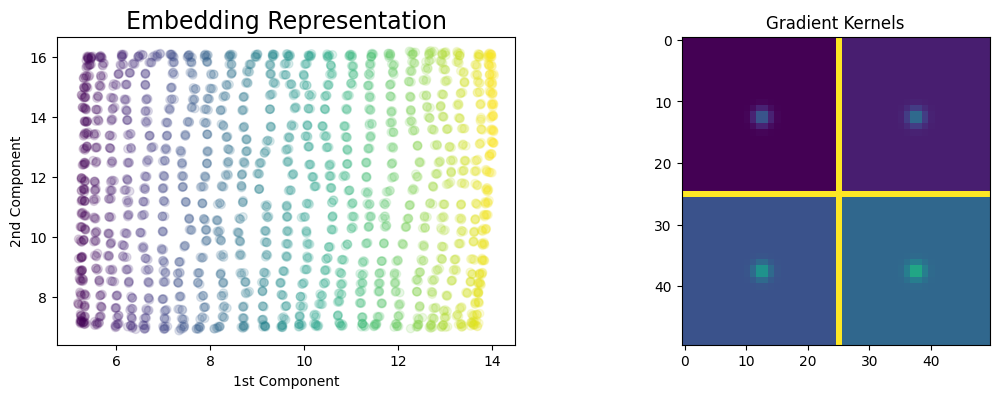

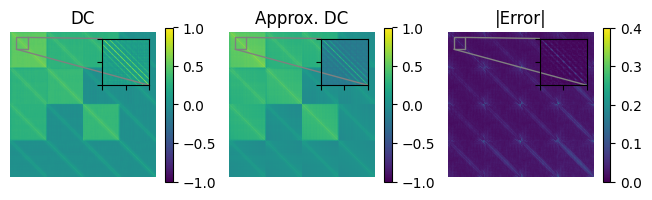

Results for UMAP
Correlation(L vs Dense_C): 0.9112541413981515
Correlation(S vs sparse): 0.8402557165288722
Correlation(L+wS vs Dense_C): 0.9659014171042769


In [11]:
# DLS (UMAP) with 2 gradient components

M2=2
embedded = umap.UMAP(n_components=M2, metric='euclidean',n_neighbors=50).fit_transform(S)
utils.display_columns(embedded[unsort_idx,:], V, V,'viridis',axis='off')
utils.display_columns(embedded[unsort_idx,:], V, V,'prism', axis='off')
if embedded.shape[1]>2:
    pca=PCA(n_components=2)
    embeddedr=pca.fit_transform(embedded)
else:
    embeddedr=embedded
    
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].scatter(embeddedr[:,0],embeddedr[:,1],c=embedded[:,0], alpha=0.15, cmap='viridis')
axs[0].set_title('Embedding Representation', fontsize=17)
axs[0].set_xlabel('1st Component')
axs[0].set_ylabel('2nd Component')

im = axs[1].imshow(np.reshape(Z.T,(V,V)),cmap='viridis')
#im=axs[1].imshow(index_pattren,cmap='viridis')
axs[1].set_title('Gradient Kernels')


approx_dist=np.zeros((V*V,V*V))

for i in range(M2):
    approx_dist+=np.abs(np.subtract.outer(embedded[:,i],embedded[:,i]))**2


approx_dist=(approx_dist)**0.5

approx_dense=(np.max(approx_dist)-approx_dist)

temp1=match_histograms(approx_dense, S)
w_opt=np.sum(temp1*S)/np.sum(temp1*temp1)
print(f'w optimal: {w_opt}')
print('Final DC:')
approx_dense=w_opt*temp1+L

utils.display_compare(approx_dense,Dense_C_train, axis='off')
print('Results for UMAP')
print('Correlation(L vs Dense_C):',np.corrcoef(L.flatten(),Dense_C_valid.flatten())[0,1])
print('Correlation(S vs sparse):',np.corrcoef(temp1.flatten(),S.flatten())[0,1])
print('Correlation(L+wS vs Dense_C):',np.corrcoef(approx_dense.flatten(),Dense_C_valid.flatten())[0,1])

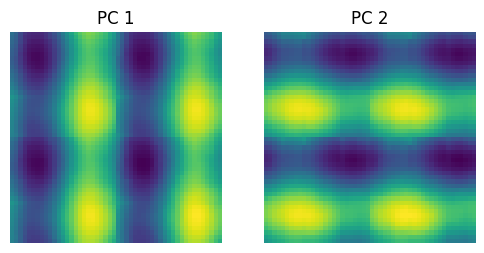

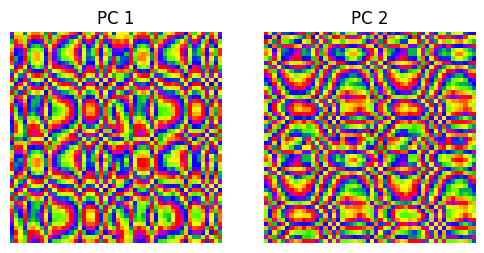

w optimal: 0.5132363014293665
Final DC:


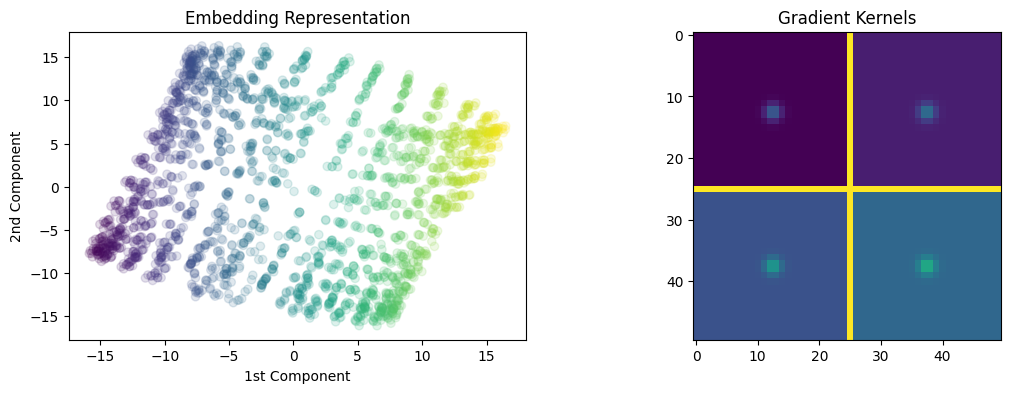

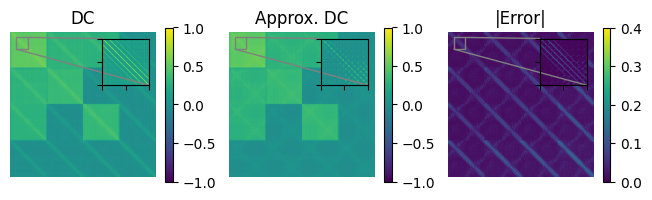

Results for ISOMAP
Correlation(L vs Dense_C): 0.9112541413981515
Correlation(S vs sparse): 0.5019439906765026
Correlation(L+wS vs Dense_C): 0.9307575485307812


In [12]:
# DLS (ISOMAP) with 2 gradient components

M2=2
embedded = Isomap(n_components=M2,n_neighbors=8).fit_transform(S)
utils.display_columns(embedded[unsort_idx,:], V, V,'viridis', axis='off')
utils.display_columns(embedded[unsort_idx,:], V, V,'prism', axis='off')
if embedded.shape[1]>2:
    pca=PCA(n_components=2)
    embeddedr=pca.fit_transform(embedded)
else:
    embeddedr=embedded
    
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].scatter(embeddedr[:,0],embeddedr[:,1],c=embedded[:,0], alpha=0.15, cmap='viridis')
axs[0].set_title('Embedding Representation')
axs[0].set_xlabel('1st Component')
axs[0].set_ylabel('2nd Component')

im = axs[1].imshow(np.reshape(Z.T,(V,V)),cmap='viridis')
#im=axs[1].imshow(index_pattren,cmap='viridis')
axs[1].set_title('Gradient Kernels')


approx_dist=np.zeros((V*V,V*V))

for i in range(M2):
    approx_dist+=np.abs(np.subtract.outer(embedded[:,i],embedded[:,i]))**2


approx_dist=(approx_dist)**0.5

approx_dense=(np.max(approx_dist)-approx_dist)

temp1=match_histograms(approx_dense, S)
w_opt=np.sum(temp1*S)/np.sum(temp1*temp1)
print(f'w optimal: {w_opt}')
print('Final DC:')
approx_dense=w_opt*temp1+L

utils.display_compare(approx_dense,Dense_C_train, axis='off')
print('Results for ISOMAP')
print('Correlation(L vs Dense_C):',np.corrcoef(L.flatten(),Dense_C_valid.flatten())[0,1])
print('Correlation(S vs sparse):',np.corrcoef(temp1.flatten(),S.flatten())[0,1])
print('Correlation(L+wS vs Dense_C):',np.corrcoef(approx_dense.flatten(),Dense_C_valid.flatten())[0,1])

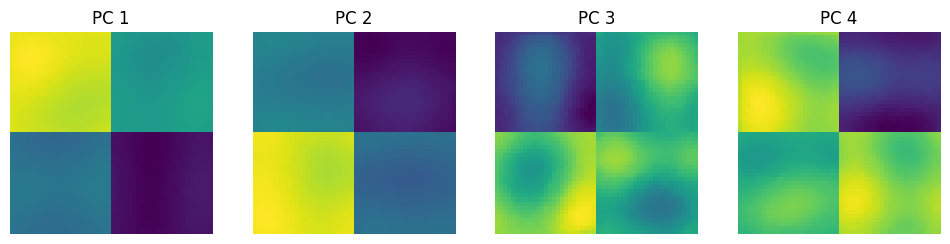

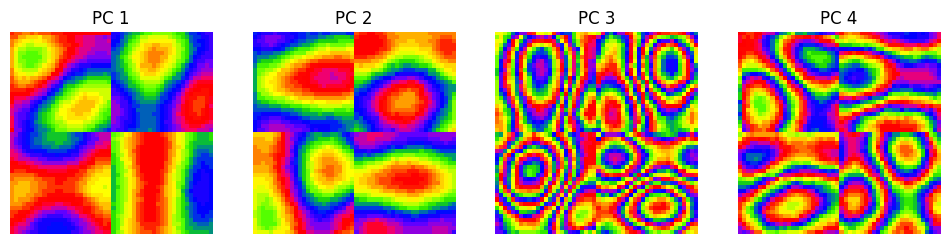

Final DC:


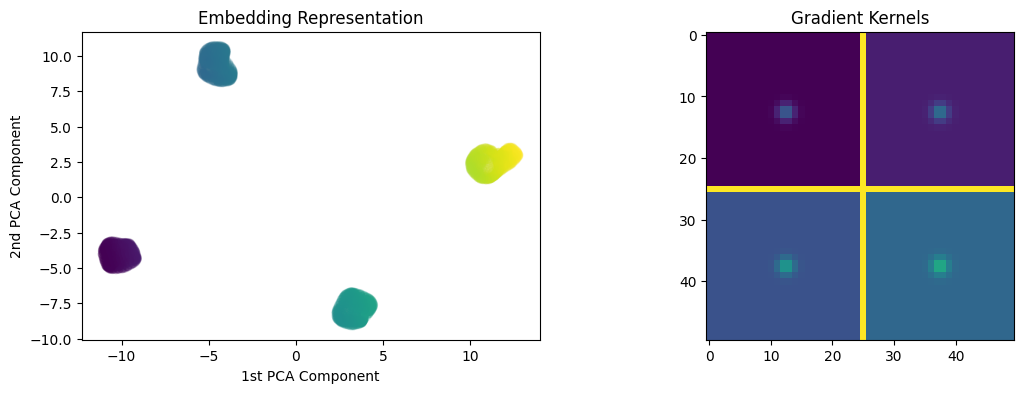

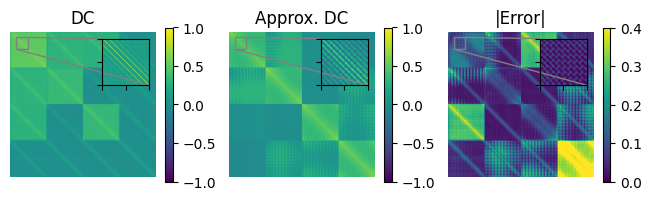

Results for UMAP
Correlation vs Dense_C: 0.46775828355823573


In [13]:
# UMAP with 4 gradient components

M2=4
embedded = umap.UMAP(n_components=M2, metric='euclidean',n_neighbors=50).fit_transform(Dense_C_train)
utils.display_columns(embedded[unsort_idx,:], V, V,'viridis', axis='off')
utils.display_columns(embedded[unsort_idx,:], V, V,'prism', axis='off')
if embedded.shape[1]>2:
    pca=PCA(n_components=2)
    embeddedr=pca.fit_transform(embedded)
else:
    embeddedr=embedded
    
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].scatter(embeddedr[:,0],embeddedr[:,1],c=embedded[:,0], alpha=0.15, cmap='viridis')
axs[0].set_title('Embedding Representation')
axs[0].set_xlabel('1st PCA Component')
axs[0].set_ylabel('2nd PCA Component')

im = axs[1].imshow(np.reshape(Z.T,(V,V)),cmap='viridis')
#im=axs[1].imshow(index_pattren,cmap='viridis')
axs[1].set_title('Gradient Kernels')


approx_dist=np.zeros((V*V,V*V))

for i in range(M2):
    approx_dist+=np.abs(np.subtract.outer(embedded[:,i],embedded[:,i]))**2


approx_dist=(approx_dist)**0.5

approx_dense=(np.max(approx_dist)-approx_dist)

temp1=match_histograms(approx_dense, Dense_C_train)

print('Final DC:')
approx_dense=temp1

utils.display_compare(approx_dense,Dense_C_train, axis='off')
print('Results for UMAP')
print('Correlation vs Dense_C:',np.corrcoef(approx_dense.flatten(),Dense_C_valid.flatten())[0,1])

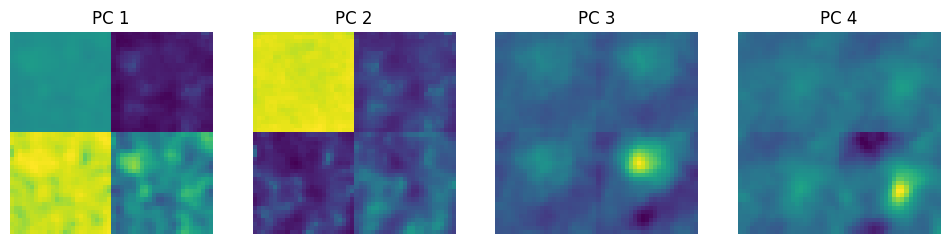

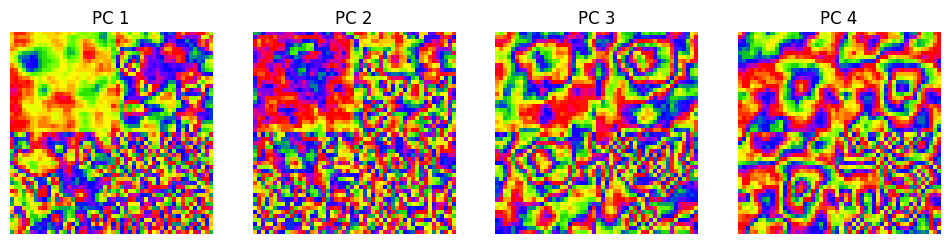

Final DC:


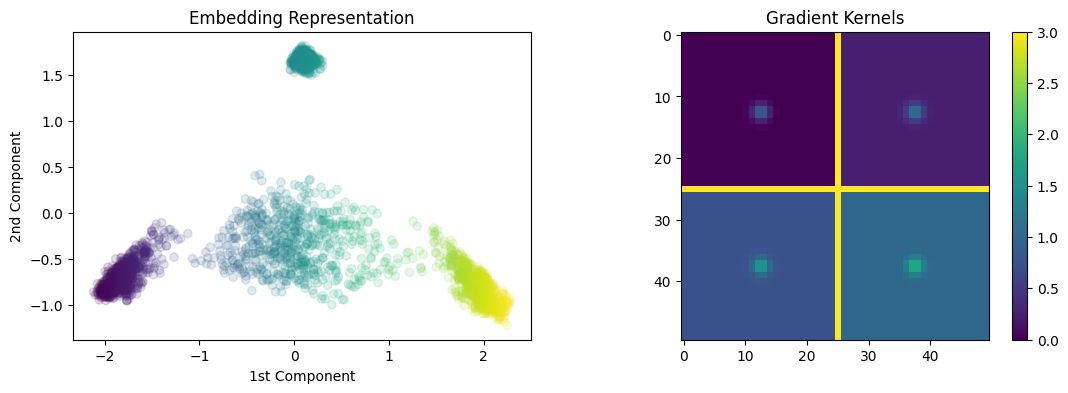

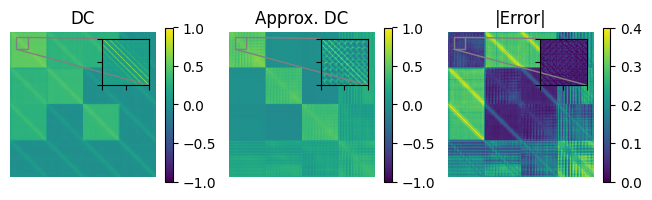

Results for DMAP
Correlation vs Dense_C: 0.2819798125602949


In [14]:
# Gradient-only with 4 gradient components

M2=4
gm = GradientMaps(n_components=M2, approach='dm',kernel='cosine')
gm.fit(Dense_C_train)
embedded = gm.gradients_
utils.display_columns(embedded[unsort_idx,:], V, V,'viridis', axis='off')
utils.display_columns(embedded[unsort_idx,:], V, V,'prism', axis='off')
if embedded.shape[1]>2:
    pca=PCA(n_components=2)
    embeddedr=pca.fit_transform(embedded)
else:
    embeddedr=embedded
    
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].scatter(embedded[:,0],embedded[:,1],c=embedded[:,0], alpha=0.15, cmap='viridis')
axs[0].set_title('Embedding Representation')
axs[0].set_xlabel('1st Component')
axs[0].set_ylabel('2nd Component')

im = axs[1].imshow(np.reshape(Z.T,(V,V)),cmap='viridis')
#im=axs[1].imshow(index_pattren,cmap='viridis')
axs[1].set_title('Gradient Kernels')
cbar = plt.colorbar(im, ax=axs[1])


approx_dist=np.zeros((V*V,V*V))

for i in range(M2):
    approx_dist+=np.abs(np.subtract.outer(embedded[:,i],embedded[:,i]))**2


approx_dist=(approx_dist)**0.5

approx_dense=(np.max(approx_dist)-approx_dist)
#approx_dense=embedded@embedded.T

temp1=match_histograms(approx_dense, Dense_C_train)

print('Final DC:')
approx_dense=temp1

utils.display_compare(approx_dense,Dense_C_train, axis='off')
print('Results for DMAP')
print('Correlation vs Dense_C:',np.corrcoef(approx_dense.flatten(),Dense_C_valid.flatten())[0,1])

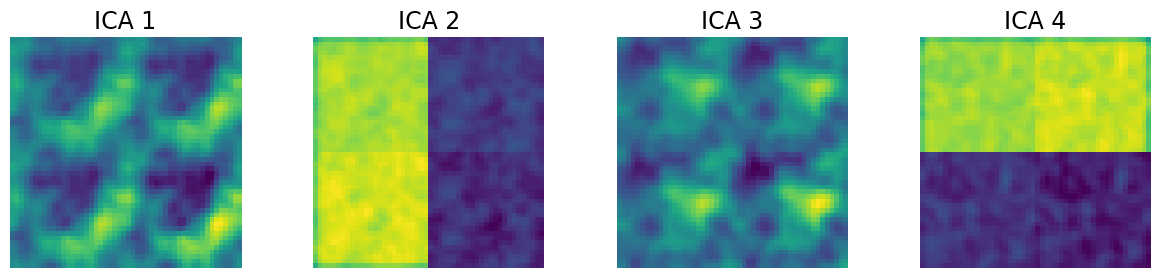

In [15]:
# ICA with 4 global components

M1=4
ica = FastICA(n_components=M1, max_iter=1000)
independent_S =ica.fit_transform(Dense_C_train)
independent_A =ica.mixing_
fig, axes = plt.subplots(1, independent_S.shape[1], figsize=(15, 3))
for ax in axes:
    ax.axis('off')
for i in range(independent_S.shape[1]):
    im=axes[i].imshow(np.reshape(independent_S[unsort_idx,i],(V,V)), cmap='viridis')  # Change the colormap if needed
    axes[i].set_title(f'ICA {i+1}', fontsize=17)
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')
plt.show()
    

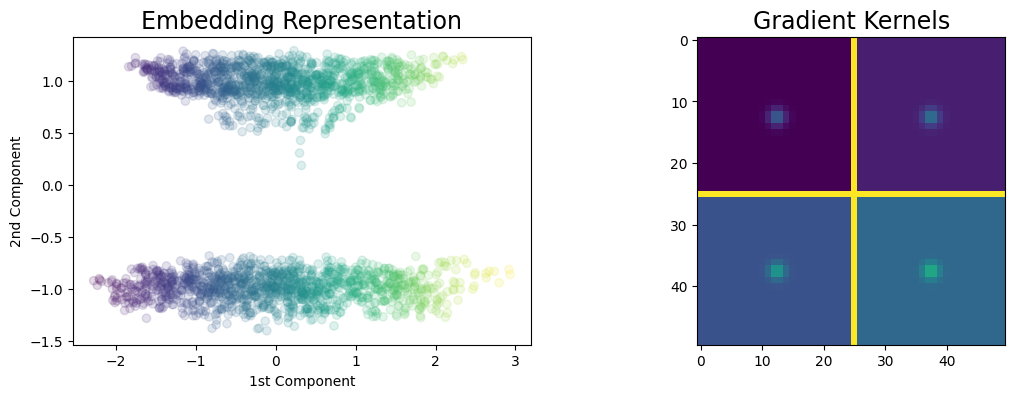

In [16]:
# Visualising the results

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].scatter(independent_S[:,0],independent_S[:,1],c=independent_S[:,0], alpha=0.15, cmap='viridis')
axs[0].set_title('Embedding Representation',fontsize=17)
axs[0].set_xlabel('1st Component')
axs[0].set_ylabel('2nd Component')

im = axs[1].imshow(np.reshape(Z.T,(V,V)),cmap='viridis')
#im=axs[1].imshow(index_pattren,cmap='viridis')
axs[1].set_title('Gradient Kernels',fontsize=17)
plt.show()

Starting fitting...


100%|███████████████████████████████████████████| 20/20 [00:09<00:00,  2.05it/s]


Not converged!
Total error: 1534.511260, allowed tolerance: 625.000000


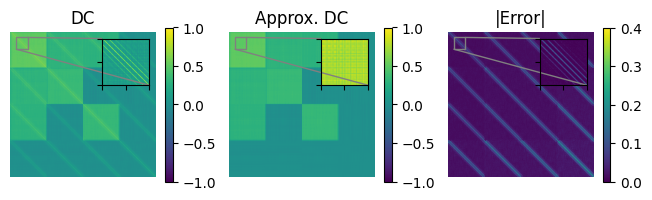

Correlation vs Dense_C: 0.9138521835959038


In [17]:
# Low-rank approximation with 4 global components

rpcp_new = RobustPCA(max_rank=4, max_iter=20, tol=0.0001*Dense_C_train.shape[0]*Dense_C_train.shape[1],use_fbpca=True)
rpcp_new.fit(Dense_C_train)
L_new = rpcp_new.get_low_rank()
utils.display_compare(L_new,Dense_C_train, axis='off')
print('Correlation vs Dense_C:',np.corrcoef(L_new.flatten(),Dense_C_valid.flatten())[0,1])